# Convolutional Neural Networks for digit image classification

Oskar Andersson - oa222jq

## Aim

The goal is to compare several CNN architectures for MNIST digit classification. The experiments focus on accuracy, learning convergence, and model complexity measured by the number of trainable parameters.

The notebook starts with a small baseline model and then tests pooling, larger convolution kernels, more filters, dense layers, augmentation, and smaller dense layers.

Using device: cpu
Train: X=torch.Size([60000, 28, 28]), y=torch.Size([60000])
Test: X=torch.Size([10000, 28, 28]), y=torch.Size([10000])


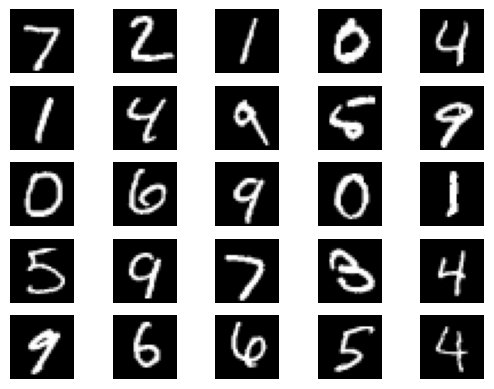

In [2]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

from matplotlib import pyplot

# Reproducibility
torch.manual_seed(42)

# Use GPU if available, otherwise CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Load MNIST dataset
train_dataset_raw = datasets.MNIST(
    root="./data",
    train=True,
    download=True
)

test_dataset_raw = datasets.MNIST(
    root="./data",
    train=False,
    download=True
)

# Summarize loaded dataset
print("Train: X=%s, y=%s" % (train_dataset_raw.data.shape, train_dataset_raw.targets.shape))
print("Test: X=%s, y=%s" % (test_dataset_raw.data.shape, test_dataset_raw.targets.shape))

# Plot first few test images
for i in range(25):
    pyplot.subplot(5, 5, i + 1)
    pyplot.imshow(test_dataset_raw.data[i], cmap=pyplot.get_cmap("gray"))
    pyplot.axis("off")

pyplot.show()

In [3]:
import numpy as np

import torch
from torch import nn
from torch.utils.data import DataLoader

from torchvision import datasets, transforms

from sklearn.metrics import accuracy_score

from matplotlib import pyplot
from tqdm import tqdm

## Baseline model

Let’s start with a very small CNN because we need a simple reference point. The baseline uses one convolutional filter and no hidden dense layer.

In [4]:
# PyTorch uses channel-first image tensors:
# Keras/TensorFlow: (N, height, width, channels)
# PyTorch:          (N, channels, height, width)

orig_shape = train_dataset_raw.data.shape[1:]

# MNIST images are grayscale, so the model input will have 1 channel.
in_channels = 1
image_height = train_dataset_raw.data.shape[1]
image_width = train_dataset_raw.data.shape[2]

print("Original image shape:", orig_shape)
print("PyTorch CNN input shape per image: ({0}, {1}, {2})".format(
    in_channels, image_height, image_width
))

Original image shape: torch.Size([28, 28])
PyTorch CNN input shape per image: (1, 28, 28)


In [5]:
n_classes = len(torch.unique(train_dataset_raw.targets))

print("Classes:", n_classes)
print("Class labels:", torch.unique(train_dataset_raw.targets).tolist())

Classes: 10
Class labels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


In [6]:
# Basic transform:
# - converts PIL image to torch.Tensor
# - scales pixel values from [0, 255] to [0.0, 1.0]
# - changes shape from (H, W) to (C, H, W)

train_transform = transforms.ToTensor()
test_transform = transforms.ToTensor()

In [7]:
def make_model(depth, kernel_width, pool_stride, add_dense=False):
    class CNNModel(nn.Module):
        def __init__(self):
            super().__init__()

            self.features = nn.Sequential(
                nn.Conv2d(
                    in_channels=1,
                    out_channels=depth,
                    kernel_size=kernel_width
                ),
                nn.ReLU(),
                nn.MaxPool2d(kernel_size=pool_stride, stride=pool_stride),
                nn.Flatten()
            )

            # Determine the flattened size automatically using a dummy image.
            with torch.no_grad():
                dummy_input = torch.zeros(1, 1, 28, 28)
                flattened_size = self.features(dummy_input).shape[1]

            if add_dense:
                self.classifier = nn.Sequential(
                    nn.Linear(flattened_size, 100),
                    nn.ReLU(),
                    nn.Dropout(0.5),
                    nn.Linear(100, n_classes)
                )
            else:
                self.classifier = nn.Linear(flattened_size, n_classes)

        def forward(self, x):
            x = self.features(x)
            x = self.classifier(x)
            return x

    model = CNNModel().to(device)
    return model

In [8]:
EPOCHS = 10
BATCH_SIZE = 128
LEARNING_RATE = 0.001
PATIENCE = 10

# Number of mini-batches per training epoch
it = round(len(train_dataset_raw) / BATCH_SIZE)

print("Mini-batches per epoch:", it)

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=train_transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=test_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Mini-batches per epoch: 469


In [9]:
def plot_metrics(history):
    metrics = ["loss", "accuracy"]
    pyplot.figure(figsize=(10, 5))

    epochs = range(1, len(history["train_loss"]) + 1)

    for n, metric in enumerate(metrics):
        name = metric.capitalize()
        pyplot.subplot(1, 2, n + 1)

        pyplot.plot(
            epochs,
            history[f"train_{metric}"],
            label="Train"
        )

        pyplot.plot(
            epochs,
            history[f"val_{metric}"],
            linestyle="--",
            label="Val"
        )

        pyplot.xlabel("Epoch")
        pyplot.ylabel(name)

        if metric == "loss":
            pyplot.ylim([0, pyplot.ylim()[1] + 0.1])
        else:
            pyplot.ylim([-0.1, 1.1])

        pyplot.legend()

    pyplot.show()

In [10]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


In [11]:
baseline = make_model(depth=1, kernel_width=1, pool_stride=1)

print(baseline)

print("Trainable parameters:", count_parameters(baseline))

CNNModel(
  (features): Sequential(
    (0): Conv2d(1, 1, kernel_size=(1, 1), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=1, stride=1, padding=0, dilation=1, ceil_mode=False)
    (3): Flatten(start_dim=1, end_dim=-1)
  )
  (classifier): Linear(in_features=784, out_features=10, bias=True)
)
Trainable parameters: 7852


In [12]:
def train_one_epoch(model, train_loader, criterion, optimizer):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(train_loader, desc="Training", leave=False):
        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Metrics
        running_loss += loss.item() * images.size(0)

        predictions = torch.argmax(outputs, dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy


def evaluate(model, data_loader, criterion):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in tqdm(data_loader, desc="Evaluating", leave=False):
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            predictions = torch.argmax(outputs, dim=1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

In [13]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(baseline.parameters(), lr=LEARNING_RATE)

baseline_history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": []
}

best_val_accuracy = 0.0
best_model_state = None
epochs_without_improvement = 0

for epoch in range(EPOCHS):
    train_loss, train_accuracy = train_one_epoch(
        baseline,
        train_loader,
        criterion,
        optimizer
    )

    val_loss, val_accuracy = evaluate(
        baseline,
        test_loader,
        criterion
    )

    baseline_history["train_loss"].append(train_loss)
    baseline_history["train_accuracy"].append(train_accuracy)
    baseline_history["val_loss"].append(val_loss)
    baseline_history["val_accuracy"].append(val_accuracy)

    print(
        f"Epoch {epoch + 1:02d}/{EPOCHS} | "
        f"train loss: {train_loss:.4f} | "
        f"train accuracy: {train_accuracy:.4f} | "
        f"val loss: {val_loss:.4f} | "
        f"val accuracy: {val_accuracy:.4f}"
    )

    # Manual early stopping based on validation accuracy
    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        best_model_state = baseline.state_dict().copy()
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= PATIENCE:
        print("Early stopping triggered.")
        break

# Restore best model weights
if best_model_state is not None:
    baseline.load_state_dict(best_model_state)

print("Best validation accuracy:", best_val_accuracy)

Epoch 01/10 | train loss: 0.9769 | train accuracy: 0.7562 | val loss: 0.4714 | val accuracy: 0.8781


Epoch 02/10 | train loss: 0.4228 | train accuracy: 0.8838 | val loss: 0.3554 | val accuracy: 0.9002


Epoch 03/10 | train loss: 0.3516 | train accuracy: 0.8996 | val loss: 0.3188 | val accuracy: 0.9108


Epoch 04/10 | train loss: 0.3215 | train accuracy: 0.9079 | val loss: 0.3061 | val accuracy: 0.9131


Epoch 05/10 | train loss: 0.3053 | train accuracy: 0.9131 | val loss: 0.2923 | val accuracy: 0.9172


Epoch 06/10 | train loss: 0.2934 | train accuracy: 0.9166 | val loss: 0.2831 | val accuracy: 0.9193


Epoch 07/10 | train loss: 0.2854 | train accuracy: 0.9196 | val loss: 0.2765 | val accuracy: 0.9216


Epoch 08/10 | train loss: 0.2798 | train accuracy: 0.9220 | val loss: 0.2760 | val accuracy: 0.9218


Epoch 09/10 | train loss: 0.2752 | train accuracy: 0.9227 | val loss: 0.2761 | val accuracy: 0.9237


Epoch 10/10 | train loss: 0.2707 | train accuracy: 0.9247 | val loss: 0.2726 | val accuracy: 0.9234
Best validation accuracy: 0.9237


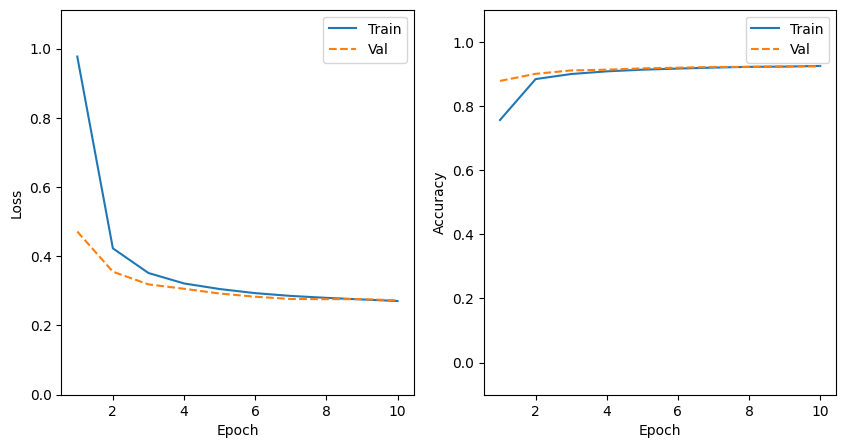

In [14]:
plot_metrics(baseline_history)

In [15]:
baseline_loss, baseline_acc = evaluate(
    baseline,
    test_loader,
    criterion
)

print("Accuracy: %.3f" % baseline_acc)
print("Loss: %.3f" % baseline_loss)

Accuracy: 0.923
Loss: 0.273


The baseline reached 0.923 accuracy with 7,852 parameters. This shows that even a very small CNN can learn MNIST reasonably well.

The learning curves also give a reference for later models: we can compare whether later changes improve accuracy, convergence, or parameter efficiency.

Predicted class: 9
True class: 9


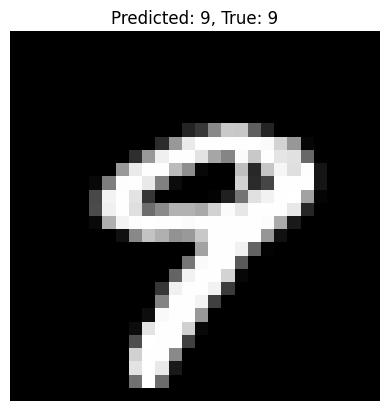

In [16]:
# Select one image from the test set
image, label = test_dataset[9]

# Add batch dimension: (C, H, W) -> (1, C, H, W)
image_batch = image.unsqueeze(0).to(device)

baseline.eval()
with torch.no_grad():
    logits = baseline(image_batch)
    prediction = torch.argmax(logits, dim=1).item()

print("Predicted class:", prediction)
print("True class:", label)

pyplot.imshow(image.squeeze(), cmap="gray")
pyplot.title(f"Predicted: {prediction}, True: {label}")
pyplot.axis("off")
pyplot.show()

In [17]:
def print_res(model, dataset=test_dataset, i_range=10):
    err = 0
    ys = np.zeros(i_range * i_range, dtype=int)

    class bcolors:
        FAIL = "\033[91m"
        ENDC = "\033[0m"

    model.eval()

    with torch.no_grad():
        for i in range(i_range):
            for j in range(i_range):
                idx = i * i_range + j

                image, true_label = dataset[idx]

                # Add batch dimension and move to device
                image_batch = image.unsqueeze(0).to(device)

                logits = model(image_batch)
                prediction = torch.argmax(logits, dim=1).item()

                ys[idx] = prediction
                print("%d " % prediction, end="")
            print()

    print("--")

    for i in range(i_range):
        for j in range(i_range):
            idx = i * i_range + j
            _, true_label = dataset[idx]

            if true_label == ys[idx]:
                print("%d " % true_label, end="")
            else:
                err += 1
                print(f"{bcolors.FAIL}%d {bcolors.ENDC}" % true_label, end="")
        print()

    return err

In [18]:
print_res(baseline)

7 2 1 0 4 1 4 9 6 9 
0 6 9 0 1 5 9 7 3 4 
9 6 6 5 4 0 7 4 0 1 
3 1 3 0 7 2 7 1 2 1 
1 7 4 2 3 5 1 2 4 4 
6 3 5 5 6 0 4 1 9 5 
7 8 9 2 7 4 7 4 3 0 
7 0 2 9 1 7 3 2 9 7 
7 6 2 7 8 4 7 3 6 1 
3 6 4 3 1 4 1 7 6 9 
--
7 2 1 0 4 1 4 9 5 9 
0 6 9 0 1 5 9 7 3 4 
9 6 6 5 4 0 7 4 0 1 
3 1 3 4 7 2 7 1 2 1 
1 7 4 2 3 5 1 2 4 4 
6 3 5 5 6 0 4 1 9 5 
7 8 9 3 7 4 6 4 3 0 
7 0 2 9 1 7 3 2 9 7 
7 6 2 7 8 4 7 3 6 1 
3 6 9 3 1 4 1 7 6 9 


5

## Model 1: Add pooling

Let’s try adding pooling because we might assume that downsampling reduces the number of parameters and gives some tolerance to small spatial shifts.

The risk is that pooling may remove useful information if the model has not yet learned meaningful local features.

In [19]:
model1 = make_model(depth=1, kernel_width=1, pool_stride=2, add_dense=False)

print(model1)
print("Trainable parameters:", count_parameters(model1))

CNNModel(
  (features): Sequential(
    (0): Conv2d(1, 1, kernel_size=(1, 1), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Flatten(start_dim=1, end_dim=-1)
  )
  (classifier): Linear(in_features=196, out_features=10, bias=True)
)
Trainable parameters: 1972


In [20]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model1.parameters(), lr=LEARNING_RATE)

model1_history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": []
}

best_val_accuracy = 0.0
best_model_state = None
epochs_without_improvement = 0

for epoch in range(EPOCHS):
    train_loss, train_accuracy = train_one_epoch(
        model1,
        train_loader,
        criterion,
        optimizer
    )

    val_loss, val_accuracy = evaluate(
        model1,
        test_loader,
        criterion
    )

    model1_history["train_loss"].append(train_loss)
    model1_history["train_accuracy"].append(train_accuracy)
    model1_history["val_loss"].append(val_loss)
    model1_history["val_accuracy"].append(val_accuracy)

    print(
        f"Epoch {epoch + 1:02d}/{EPOCHS} | "
        f"train loss: {train_loss:.4f} | "
        f"train accuracy: {train_accuracy:.4f} | "
        f"val loss: {val_loss:.4f} | "
        f"val accuracy: {val_accuracy:.4f}"
    )

    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        best_model_state = {
            key: value.cpu().clone()
            for key, value in model1.state_dict().items()
        }
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= PATIENCE:
        print("Early stopping triggered.")
        break

if best_model_state is not None:
    model1.load_state_dict(best_model_state)

print("Best validation accuracy:", best_val_accuracy)

Epoch 01/10 | train loss: 2.3019 | train accuracy: 0.1084 | val loss: 2.3011 | val accuracy: 0.1135


Epoch 02/10 | train loss: 2.3013 | train accuracy: 0.1124 | val loss: 2.3011 | val accuracy: 0.1135


Epoch 03/10 | train loss: 2.3013 | train accuracy: 0.1124 | val loss: 2.3010 | val accuracy: 0.1135


Epoch 04/10 | train loss: 2.3013 | train accuracy: 0.1124 | val loss: 2.3011 | val accuracy: 0.1135


Epoch 05/10 | train loss: 2.3013 | train accuracy: 0.1124 | val loss: 2.3010 | val accuracy: 0.1135


Epoch 06/10 | train loss: 2.3013 | train accuracy: 0.1124 | val loss: 2.3010 | val accuracy: 0.1135


Epoch 07/10 | train loss: 2.3013 | train accuracy: 0.1124 | val loss: 2.3010 | val accuracy: 0.1135


Epoch 08/10 | train loss: 2.3013 | train accuracy: 0.1124 | val loss: 2.3010 | val accuracy: 0.1135


Epoch 09/10 | train loss: 2.3013 | train accuracy: 0.1124 | val loss: 2.3010 | val accuracy: 0.1135


Epoch 10/10 | train loss: 2.3013 | train accuracy: 0.1124 | val loss: 2.3011 | val accuracy: 0.1135
Best validation accuracy: 0.1135


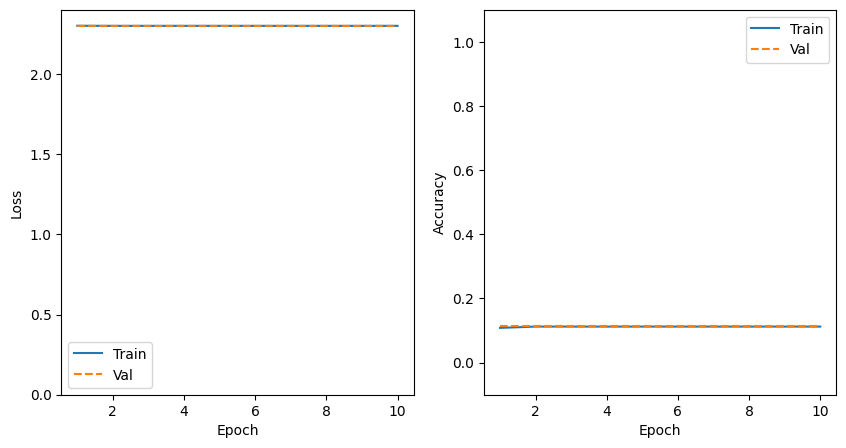

In [21]:
plot_metrics(model1_history)

In [22]:
model1_loss, model1_acc = evaluate(
    model1,
    test_loader,
    criterion
)

print("Accuracy: %.3f" % model1_acc)
print("Loss: %.3f" % model1_loss)

print("Baseline accuracy: %.3f" % baseline_acc)
print("Model 1 accuracy: %.3f" % model1_acc)

print("Baseline parameters:", count_parameters(baseline))
print("Model 1 parameters:", count_parameters(model1))

Accuracy: 0.114
Loss: 2.301
Baseline accuracy: 0.923
Model 1 accuracy: 0.114
Baseline parameters: 7852
Model 1 parameters: 1972


Model 1 reduced the parameter count to 1,972, but accuracy dropped to 0.114. This suggests that the model became too limited.

A 1×1 convolution does not learn local spatial patterns, and pooling then reduces the image before useful features have been extracted.

In [23]:
err = print_res(model1)
print("Errors in first 100 test images:", err)

1 1 1 1 1 1 1 1 1 1 
1 1 1 1 1 1 1 1 1 1 
1 1 1 1 1 1 1 1 1 1 
1 1 1 1 1 1 1 1 1 1 
1 1 1 1 1 1 1 1 1 1 
1 1 1 1 1 1 1 1 1 1 
1 1 1 1 1 1 1 1 1 1 
1 1 1 1 1 1 1 1 1 1 
1 1 1 1 1 1 1 1 1 1 
1 1 1 1 1 1 1 1 1 1 
--
7 2 1 0 4 1 4 9 5 9 
0 6 9 0 1 5 9 7 3 4 
9 6 6 5 4 0 7 4 0 1 
3 1 3 4 7 2 7 1 2 1 
1 7 4 2 3 5 1 2 4 4 
6 3 5 5 6 0 4 1 9 5 
7 8 9 3 7 4 6 4 3 0 
7 0 2 9 1 7 3 2 9 7 
7 6 2 7 8 4 7 3 6 1 
3 6 9 3 1 4 1 7 6 9 
Errors in first 100 test images: 86


## Model 2: Use a 3×3 convolution

Let’s try a 3×3 convolution because we might assume that neighboring pixels contain useful stroke information.

Compared with a 1×1 convolution, a 3×3 kernel can learn local patterns such as edges, curves, and small digit strokes.

In [24]:
model2 = make_model(depth=1, kernel_width=3, pool_stride=2, add_dense=False)

print(model2)
print("Trainable parameters:", count_parameters(model2))

CNNModel(
  (features): Sequential(
    (0): Conv2d(1, 1, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Flatten(start_dim=1, end_dim=-1)
  )
  (classifier): Linear(in_features=169, out_features=10, bias=True)
)
Trainable parameters: 1710


In [25]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model2.parameters(), lr=LEARNING_RATE)

model2_history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": []
}

best_val_accuracy = 0.0
best_model_state = None
epochs_without_improvement = 0

for epoch in range(EPOCHS):
    train_loss, train_accuracy = train_one_epoch(
        model2,
        train_loader,
        criterion,
        optimizer
    )

    val_loss, val_accuracy = evaluate(
        model2,
        test_loader,
        criterion
    )

    model2_history["train_loss"].append(train_loss)
    model2_history["train_accuracy"].append(train_accuracy)
    model2_history["val_loss"].append(val_loss)
    model2_history["val_accuracy"].append(val_accuracy)

    print(
        f"Epoch {epoch + 1:02d}/{EPOCHS} | "
        f"train loss: {train_loss:.4f} | "
        f"train accuracy: {train_accuracy:.4f} | "
        f"val loss: {val_loss:.4f} | "
        f"val accuracy: {val_accuracy:.4f}"
    )

    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        best_model_state = {
            key: value.cpu().clone()
            for key, value in model2.state_dict().items()
        }
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= PATIENCE:
        print("Early stopping triggered.")
        break

if best_model_state is not None:
    model2.load_state_dict(best_model_state)

print("Best validation accuracy:", best_val_accuracy)

Epoch 01/10 | train loss: 0.8721 | train accuracy: 0.7799 | val loss: 0.3739 | val accuracy: 0.8978


Epoch 02/10 | train loss: 0.3573 | train accuracy: 0.8965 | val loss: 0.3202 | val accuracy: 0.9085


Epoch 03/10 | train loss: 0.3233 | train accuracy: 0.9053 | val loss: 0.2989 | val accuracy: 0.9124


Epoch 04/10 | train loss: 0.3087 | train accuracy: 0.9103 | val loss: 0.2889 | val accuracy: 0.9164


Epoch 05/10 | train loss: 0.3000 | train accuracy: 0.9125 | val loss: 0.2883 | val accuracy: 0.9145


Epoch 06/10 | train loss: 0.2941 | train accuracy: 0.9145 | val loss: 0.2796 | val accuracy: 0.9158


Epoch 07/10 | train loss: 0.2898 | train accuracy: 0.9160 | val loss: 0.2765 | val accuracy: 0.9194


Epoch 08/10 | train loss: 0.2864 | train accuracy: 0.9174 | val loss: 0.2716 | val accuracy: 0.9226


Epoch 09/10 | train loss: 0.2834 | train accuracy: 0.9182 | val loss: 0.2705 | val accuracy: 0.9212


Epoch 10/10 | train loss: 0.2815 | train accuracy: 0.9186 | val loss: 0.2697 | val accuracy: 0.9214
Best validation accuracy: 0.9226


In [26]:
print("Baseline parameters:", count_parameters(baseline))
print("Model 1 parameters:", count_parameters(model1))
print("Model 2 parameters:", count_parameters(model2))

Baseline parameters: 7852
Model 1 parameters: 1972
Model 2 parameters: 1710


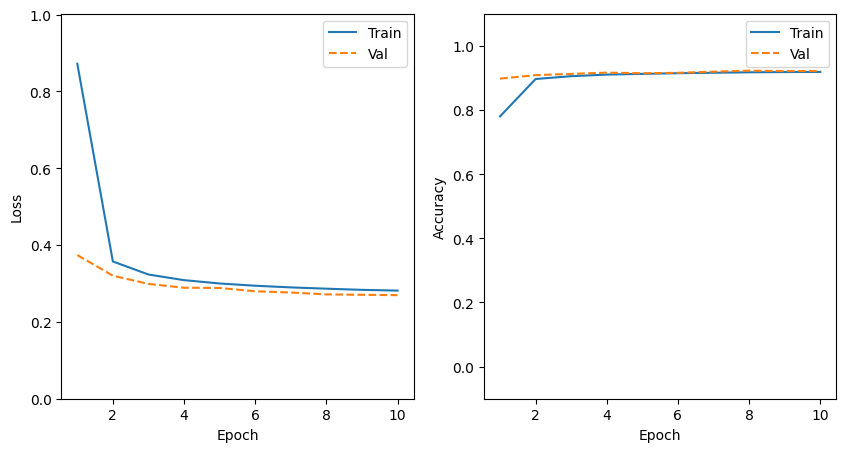

In [27]:
plot_metrics(model2_history)

In [28]:
model2_loss, model2_acc = evaluate(
    model2,
    test_loader,
    criterion
)

print("Accuracy: %.3f" % model2_acc)
print("Loss: %.3f" % model2_loss)


Accuracy: 0.923
Loss: 0.272


In [29]:
print("Baseline accuracy: %.3f" % baseline_acc)
print("Model 1 accuracy: %.3f" % model1_acc)
print("Model 2 accuracy: %.3f" % model2_acc)

print("Baseline parameters:", count_parameters(baseline))
print("Model 1 parameters:", count_parameters(model1))
print("Model 2 parameters:", count_parameters(model2))

Baseline accuracy: 0.923
Model 1 accuracy: 0.114
Model 2 accuracy: 0.923
Baseline parameters: 7852
Model 1 parameters: 1972
Model 2 parameters: 1710


Model 2 reached 0.923 accuracy with only 1,710 parameters. This matched the baseline accuracy while using far fewer parameters.

The result suggests that a small spatial kernel is much more effective than a 1×1 convolution for image classification.

In [30]:
err = print_res(model2)
print("Errors in first 100 test images:", err)

7 2 1 0 4 1 4 9 6 9 
0 6 9 0 1 5 9 7 3 4 
9 6 6 5 4 0 7 4 0 1 
3 1 3 6 7 2 7 1 2 1 
1 7 4 2 3 5 1 2 4 4 
6 3 5 5 6 0 4 1 9 5 
7 8 9 2 7 4 2 4 3 0 
7 0 2 9 1 7 3 2 9 7 
7 6 2 7 8 4 7 3 6 1 
3 6 4 3 1 4 1 7 6 9 
--
7 2 1 0 4 1 4 9 5 9 
0 6 9 0 1 5 9 7 3 4 
9 6 6 5 4 0 7 4 0 1 
3 1 3 4 7 2 7 1 2 1 
1 7 4 2 3 5 1 2 4 4 
6 3 5 5 6 0 4 1 9 5 
7 8 9 3 7 4 6 4 3 0 
7 0 2 9 1 7 3 2 9 7 
7 6 2 7 8 4 7 3 6 1 
3 6 9 3 1 4 1 7 6 9 
Errors in first 100 test images: 5


## Model 3: Increase the number of filters

Let’s try increasing the number of convolutional filters from 1 to 32 because we might assume that different filters can learn different digit features.

This should increase accuracy, but it will also increase model complexity.

In [31]:
model3 = make_model(depth=32, kernel_width=3, pool_stride=2, add_dense=False)

print(model3)
print("Trainable parameters:", count_parameters(model3))

CNNModel(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Flatten(start_dim=1, end_dim=-1)
  )
  (classifier): Linear(in_features=5408, out_features=10, bias=True)
)
Trainable parameters: 54410


In [32]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model3.parameters(), lr=LEARNING_RATE)

model3_history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": []
}

best_val_accuracy = 0.0
best_model_state = None
epochs_without_improvement = 0

for epoch in range(EPOCHS):
    train_loss, train_accuracy = train_one_epoch(
        model3,
        train_loader,
        criterion,
        optimizer
    )

    val_loss, val_accuracy = evaluate(
        model3,
        test_loader,
        criterion
    )

    model3_history["train_loss"].append(train_loss)
    model3_history["train_accuracy"].append(train_accuracy)
    model3_history["val_loss"].append(val_loss)
    model3_history["val_accuracy"].append(val_accuracy)

    print(
        f"Epoch {epoch + 1:02d}/{EPOCHS} | "
        f"train loss: {train_loss:.4f} | "
        f"train accuracy: {train_accuracy:.4f} | "
        f"val loss: {val_loss:.4f} | "
        f"val accuracy: {val_accuracy:.4f}"
    )

    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        best_model_state = {
            key: value.cpu().clone()
            for key, value in model3.state_dict().items()
        }
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= PATIENCE:
        print("Early stopping triggered.")
        break

if best_model_state is not None:
    model3.load_state_dict(best_model_state)

print("Best validation accuracy:", best_val_accuracy)

Epoch 01/10 | train loss: 0.3393 | train accuracy: 0.9040 | val loss: 0.1611 | val accuracy: 0.9559


Epoch 02/10 | train loss: 0.1299 | train accuracy: 0.9642 | val loss: 0.1077 | val accuracy: 0.9679


Epoch 03/10 | train loss: 0.0896 | train accuracy: 0.9747 | val loss: 0.0753 | val accuracy: 0.9783


Epoch 04/10 | train loss: 0.0709 | train accuracy: 0.9804 | val loss: 0.0664 | val accuracy: 0.9793


Epoch 05/10 | train loss: 0.0599 | train accuracy: 0.9828 | val loss: 0.0608 | val accuracy: 0.9810


Epoch 06/10 | train loss: 0.0525 | train accuracy: 0.9848 | val loss: 0.0605 | val accuracy: 0.9815


Epoch 07/10 | train loss: 0.0463 | train accuracy: 0.9865 | val loss: 0.0603 | val accuracy: 0.9813


Epoch 08/10 | train loss: 0.0416 | train accuracy: 0.9875 | val loss: 0.0546 | val accuracy: 0.9822


Epoch 09/10 | train loss: 0.0382 | train accuracy: 0.9887 | val loss: 0.0625 | val accuracy: 0.9807


Epoch 10/10 | train loss: 0.0340 | train accuracy: 0.9899 | val loss: 0.0572 | val accuracy: 0.9819
Best validation accuracy: 0.9822


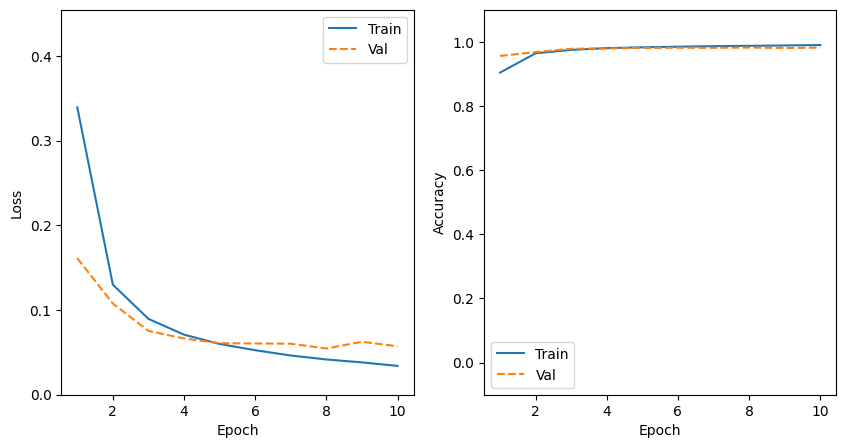

In [33]:
plot_metrics(model3_history)

In [34]:
model3_loss, model3_acc = evaluate(
    model3,
    test_loader,
    criterion
)

print("Accuracy: %.3f" % model3_acc)
print("Loss: %.3f" % model3_loss)

Accuracy: 0.982
Loss: 0.055


In [35]:
print("Baseline accuracy: %.3f" % baseline_acc)
print("Model 1 accuracy: %.3f" % model1_acc)
print("Model 2 accuracy: %.3f" % model2_acc)
print("Model 3 accuracy: %.3f" % model3_acc)

print()
print("Baseline parameters:", count_parameters(baseline))
print("Model 1 parameters:", count_parameters(model1))
print("Model 2 parameters:", count_parameters(model2))
print("Model 3 parameters:", count_parameters(model3))

Baseline accuracy: 0.923
Model 1 accuracy: 0.114
Model 2 accuracy: 0.923
Model 3 accuracy: 0.982

Baseline parameters: 7852
Model 1 parameters: 1972
Model 2 parameters: 1710
Model 3 parameters: 54410


Model 3 reached 0.982 accuracy with 54,410 parameters. This is a large accuracy improvement compared with the smaller models.

The result supports the assumption that multiple convolutional filters help the CNN learn a richer set of digit features.

In [36]:
err = print_res(model3)
print("Errors in first 100 test images:", err)

7 2 1 0 4 1 4 9 5 9 
0 6 9 0 1 5 9 7 8 4 
9 6 6 5 4 0 7 4 0 1 
3 1 3 4 7 2 7 1 2 1 
1 7 4 2 3 5 1 2 4 4 
6 3 5 5 6 0 4 1 9 5 
7 8 9 3 7 4 6 4 3 0 
7 0 2 9 1 7 3 2 9 7 
7 6 2 7 8 4 7 3 6 1 
3 6 9 3 1 4 1 7 6 9 
--
7 2 1 0 4 1 4 9 5 9 
0 6 9 0 1 5 9 7 3 4 
9 6 6 5 4 0 7 4 0 1 
3 1 3 4 7 2 7 1 2 1 
1 7 4 2 3 5 1 2 4 4 
6 3 5 5 6 0 4 1 9 5 
7 8 9 3 7 4 6 4 3 0 
7 0 2 9 1 7 3 2 9 7 
7 6 2 7 8 4 7 3 6 1 
3 6 9 3 1 4 1 7 6 9 
Errors in first 100 test images: 1


## Model 4: Add a dense hidden layer

Let’s try adding a dense hidden layer because we might assume that the classifier can combine convolutional features more effectively.

The expected benefit is higher accuracy. The expected cost is a much larger number of parameters.

In [37]:
model4 = make_model(depth=32, kernel_width=3, pool_stride=2, add_dense=True)

print(model4)
print("Trainable parameters:", count_parameters(model4))

CNNModel(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Flatten(start_dim=1, end_dim=-1)
  )
  (classifier): Sequential(
    (0): Linear(in_features=5408, out_features=100, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=100, out_features=10, bias=True)
  )
)
Trainable parameters: 542230


In [38]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model4.parameters(), lr=LEARNING_RATE)

model4_history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": []
}

best_val_accuracy = 0.0
best_model_state = None
epochs_without_improvement = 0

for epoch in range(EPOCHS):
    train_loss, train_accuracy = train_one_epoch(
        model4,
        train_loader,
        criterion,
        optimizer
    )

    val_loss, val_accuracy = evaluate(
        model4,
        test_loader,
        criterion
    )

    model4_history["train_loss"].append(train_loss)
    model4_history["train_accuracy"].append(train_accuracy)
    model4_history["val_loss"].append(val_loss)
    model4_history["val_accuracy"].append(val_accuracy)

    print(
        f"Epoch {epoch + 1:02d}/{EPOCHS} | "
        f"train loss: {train_loss:.4f} | "
        f"train accuracy: {train_accuracy:.4f} | "
        f"val loss: {val_loss:.4f} | "
        f"val accuracy: {val_accuracy:.4f}"
    )

    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        best_model_state = {
            key: value.cpu().clone()
            for key, value in model4.state_dict().items()
        }
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= PATIENCE:
        print("Early stopping triggered.")
        break

if best_model_state is not None:
    model4.load_state_dict(best_model_state)



Epoch 01/10 | train loss: 0.5836 | train accuracy: 0.8173 | val loss: 0.1694 | val accuracy: 0.9488


Epoch 02/10 | train loss: 0.2614 | train accuracy: 0.9234 | val loss: 0.0998 | val accuracy: 0.9715


Epoch 03/10 | train loss: 0.1933 | train accuracy: 0.9431 | val loss: 0.0733 | val accuracy: 0.9758


Epoch 04/10 | train loss: 0.1569 | train accuracy: 0.9527 | val loss: 0.0625 | val accuracy: 0.9788


Epoch 05/10 | train loss: 0.1371 | train accuracy: 0.9585 | val loss: 0.0585 | val accuracy: 0.9803


Epoch 06/10 | train loss: 0.1245 | train accuracy: 0.9627 | val loss: 0.0557 | val accuracy: 0.9815


Epoch 07/10 | train loss: 0.1112 | train accuracy: 0.9656 | val loss: 0.0522 | val accuracy: 0.9822


Epoch 08/10 | train loss: 0.1042 | train accuracy: 0.9686 | val loss: 0.0500 | val accuracy: 0.9826


Epoch 09/10 | train loss: 0.0966 | train accuracy: 0.9699 | val loss: 0.0460 | val accuracy: 0.9846


Epoch 10/10 | train loss: 0.0903 | train accuracy: 0.9721 | val loss: 0.0489 | val accuracy: 0.9837


In [39]:
print("Best validation accuracy:", best_val_accuracy)

Best validation accuracy: 0.9846


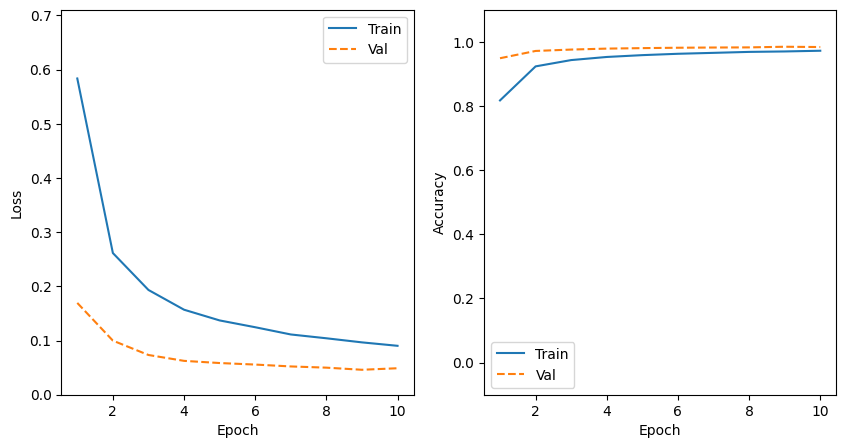

In [40]:
plot_metrics(model4_history)

Model 4 reached the highest accuracy, 0.985, but required 542,230 parameters.

The accuracy improvement over Model 3 was small compared with the large increase in model complexity. This suggests that the dense layer helps, but is not very parameter-efficient.

In [41]:
err = print_res(model4)
print("Errors in first 100 test images:", err)

7 2 1 0 4 1 4 9 5 9 
0 6 9 0 1 5 9 7 3 4 
9 6 6 5 4 0 7 4 0 1 
3 1 3 4 7 2 7 1 2 1 
1 7 4 2 3 5 1 2 4 4 
6 3 5 5 6 0 4 1 9 5 
7 8 9 3 7 4 6 4 3 0 
7 0 2 9 1 7 3 2 9 7 
7 6 2 7 8 4 7 3 6 1 
3 6 9 3 1 4 1 7 6 9 
--
7 2 1 0 4 1 4 9 5 9 
0 6 9 0 1 5 9 7 3 4 
9 6 6 5 4 0 7 4 0 1 
3 1 3 4 7 2 7 1 2 1 
1 7 4 2 3 5 1 2 4 4 
6 3 5 5 6 0 4 1 9 5 
7 8 9 3 7 4 6 4 3 0 
7 0 2 9 1 7 3 2 9 7 
7 6 2 7 8 4 7 3 6 1 
3 6 9 3 1 4 1 7 6 9 
Errors in first 100 test images: 0


# Extensions

The extensions test three changes: mild augmentation, a compact CNN with more convolutional structure, and a smaller dense layer.

The aim is to either reduce the number of parameters or improve accuracy without making the model unnecessarily large.

In [42]:
def train_model(model, train_loader, val_loader, epochs=EPOCHS, lr=LEARNING_RATE, patience=PATIENCE):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {
        "train_loss": [],
        "train_accuracy": [],
        "val_loss": [],
        "val_accuracy": []
    }

    best_val_accuracy = 0.0
    best_model_state = None
    epochs_without_improvement = 0

    for epoch in range(epochs):
        train_loss, train_accuracy = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer
        )

        val_loss, val_accuracy = evaluate(
            model,
            val_loader,
            criterion
        )

        history["train_loss"].append(train_loss)
        history["train_accuracy"].append(train_accuracy)
        history["val_loss"].append(val_loss)
        history["val_accuracy"].append(val_accuracy)

        print(
            f"Epoch {epoch + 1:02d}/{epochs} | "
            f"train loss: {train_loss:.4f} | "
            f"train accuracy: {train_accuracy:.4f} | "
            f"val loss: {val_loss:.4f} | "
            f"val accuracy: {val_accuracy:.4f}"
        )

        if val_accuracy > best_val_accuracy:
            best_val_accuracy = val_accuracy
            best_model_state = {
                key: value.cpu().clone()
                for key, value in model.state_dict().items()
            }
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            print("Early stopping triggered.")
            break

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    print("Best validation accuracy:", best_val_accuracy)

    return history

## Extension 1: Mild augmentation

Let’s try mild augmentation because handwritten digits can vary slightly in rotation, scale, and position.

The translation is kept small because MNIST digits are centered. Strong translation could move important digit information away from the expected image region.

In [43]:
augmented_train_transform = transforms.Compose([
    transforms.RandomRotation(degrees=10),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05),
        scale=(0.95, 1.05)
    ),
    transforms.ToTensor()
])

augmented_train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=augmented_train_transform
)

augmented_train_loader = DataLoader(
    augmented_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

## Extension 2: Compact CNN with adaptive pooling

Let’s try a compact CNN with two convolutional blocks because we might assume that a deeper feature extractor can learn more useful digit representations.

Instead of using a large dense layer, this model uses adaptive average pooling. This should reduce model complexity because the final classifier receives only one value per feature map.

In [44]:
class CompactCNN(nn.Module):
    def __init__(self, n_classes=10):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(32, n_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [45]:
compact_model = CompactCNN(n_classes=n_classes).to(device)

print(compact_model)
print("Trainable parameters:", count_parameters(compact_model))

CompactCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): AdaptiveAvgPool2d(output_size=(1, 1))
    (1): Flatten(start_dim=1, end_dim=-1)
    (2): Linear(in_features=32, out_features=10, bias=True)
  )
)
Trainable parameters: 5130


In [46]:
compact_history = train_model(
    compact_model,
    train_loader,
    test_loader,
    epochs=EPOCHS,
    lr=LEARNING_RATE,
    patience=PATIENCE
)

Epoch 01/10 | train loss: 1.9256 | train accuracy: 0.3102 | val loss: 1.5121 | val accuracy: 0.4906


Epoch 02/10 | train loss: 1.2900 | train accuracy: 0.5804 | val loss: 1.0865 | val accuracy: 0.6514


Epoch 03/10 | train loss: 0.9964 | train accuracy: 0.6957 | val loss: 0.8881 | val accuracy: 0.7048


Epoch 04/10 | train loss: 0.8139 | train accuracy: 0.7555 | val loss: 0.7143 | val accuracy: 0.7837


Epoch 05/10 | train loss: 0.6929 | train accuracy: 0.7929 | val loss: 0.6212 | val accuracy: 0.8132


Epoch 06/10 | train loss: 0.6061 | train accuracy: 0.8207 | val loss: 0.5458 | val accuracy: 0.8369


Epoch 07/10 | train loss: 0.5419 | train accuracy: 0.8412 | val loss: 0.4942 | val accuracy: 0.8510


Epoch 08/10 | train loss: 0.4927 | train accuracy: 0.8561 | val loss: 0.4399 | val accuracy: 0.8691


Epoch 09/10 | train loss: 0.4515 | train accuracy: 0.8680 | val loss: 0.4157 | val accuracy: 0.8761


Epoch 10/10 | train loss: 0.4191 | train accuracy: 0.8786 | val loss: 0.3855 | val accuracy: 0.8847
Best validation accuracy: 0.8847


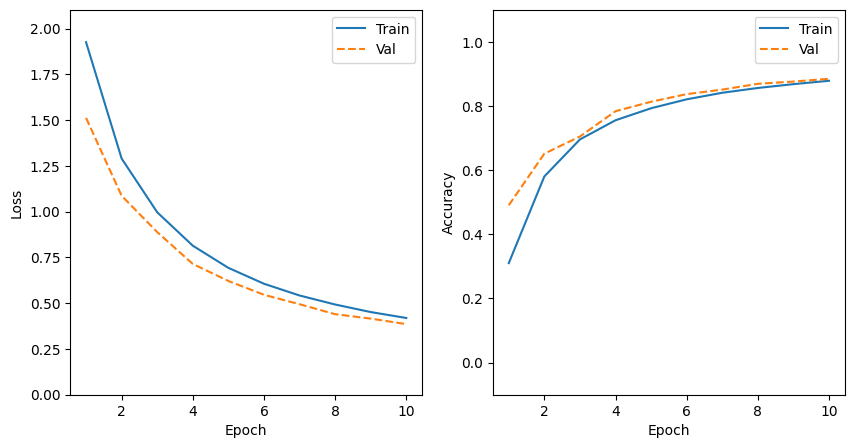

In [47]:
plot_metrics(compact_history)

In [48]:
compact_loss, compact_acc = evaluate(
    compact_model,
    test_loader,
    nn.CrossEntropyLoss()
)

print("Compact CNN accuracy: %.3f" % compact_acc)
print("Compact CNN loss: %.3f" % compact_loss)
print("Compact CNN parameters:", count_parameters(compact_model))

Compact CNN accuracy: 0.885
Compact CNN loss: 0.385
Compact CNN parameters: 5130


The compact CNN used only 5,130 parameters, but reached 0.885 accuracy. The model was parameter-efficient, but the accuracy was lower than the stronger convolutional models.

This suggests that adaptive average pooling compressed the spatial information too aggressively for this architecture.

## Extension 3: Compact CNN with augmentation

Let’s train the compact CNN with mild augmentation because we might assume that more varied training examples improve generalization.

Augmentation does not change the number of parameters, but it can affect convergence because the training data becomes more variable.

In [49]:
compact_augmented_model = CompactCNN(n_classes=n_classes).to(device)

print(compact_augmented_model)
print("Trainable parameters:", count_parameters(compact_augmented_model))

CompactCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): AdaptiveAvgPool2d(output_size=(1, 1))
    (1): Flatten(start_dim=1, end_dim=-1)
    (2): Linear(in_features=32, out_features=10, bias=True)
  )
)
Trainable parameters: 5130


In [50]:
compact_augmented_history = train_model(
    compact_augmented_model,
    augmented_train_loader,
    test_loader,
    epochs=EPOCHS,
    lr=LEARNING_RATE,
    patience=PATIENCE
)

Epoch 01/10 | train loss: 1.9854 | train accuracy: 0.2700 | val loss: 1.5884 | val accuracy: 0.4201


Epoch 02/10 | train loss: 1.4392 | train accuracy: 0.5118 | val loss: 1.1808 | val accuracy: 0.6131


Epoch 03/10 | train loss: 1.1508 | train accuracy: 0.6387 | val loss: 0.9114 | val accuracy: 0.7393


Epoch 04/10 | train loss: 0.9666 | train accuracy: 0.7017 | val loss: 0.7563 | val accuracy: 0.7762


Epoch 05/10 | train loss: 0.8489 | train accuracy: 0.7384 | val loss: 0.6711 | val accuracy: 0.8024


Epoch 06/10 | train loss: 0.7629 | train accuracy: 0.7669 | val loss: 0.5773 | val accuracy: 0.8394


Epoch 07/10 | train loss: 0.6877 | train accuracy: 0.7910 | val loss: 0.5238 | val accuracy: 0.8529


Epoch 08/10 | train loss: 0.6333 | train accuracy: 0.8098 | val loss: 0.4713 | val accuracy: 0.8683


Epoch 09/10 | train loss: 0.5794 | train accuracy: 0.8258 | val loss: 0.4324 | val accuracy: 0.8769


Epoch 10/10 | train loss: 0.5402 | train accuracy: 0.8374 | val loss: 0.3966 | val accuracy: 0.8876
Best validation accuracy: 0.8876


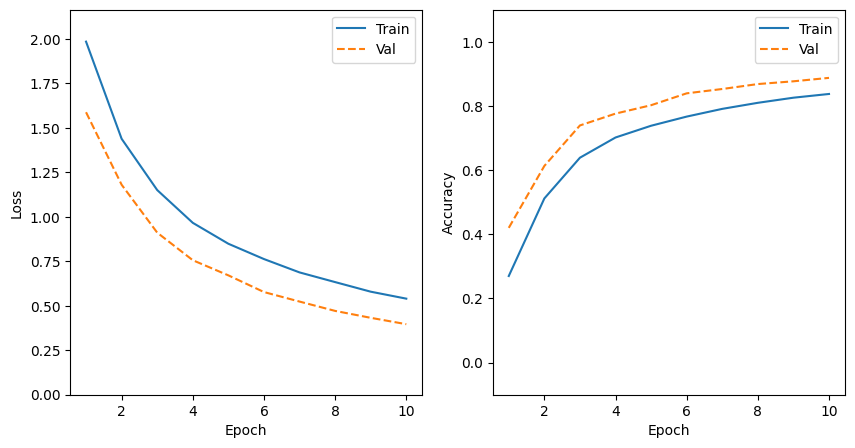

In [51]:
plot_metrics(compact_augmented_history)

In [52]:
compact_augmented_loss, compact_augmented_acc = evaluate(
    compact_augmented_model,
    test_loader,
    nn.CrossEntropyLoss()
)

print("Compact augmented CNN accuracy: %.3f" % compact_augmented_acc)
print("Compact augmented CNN loss: %.3f" % compact_augmented_loss)
print("Compact augmented CNN parameters:", count_parameters(compact_augmented_model))

Compact augmented CNN accuracy: 0.888
Compact augmented CNN loss: 0.397
Compact augmented CNN parameters: 5130


The augmented compact CNN improved slightly from 0.885 to 0.888 accuracy, while keeping the same 5,130 parameters.

The effect of augmentation was small in this experiment. It did not hurt the model, but it also did not solve the compact model’s lower accuracy.

## Extension 4: Smaller dense layer

Let’s shrink the dense hidden layer because we might assume that the original dense layer adds more parameters than necessary.

The goal is to keep most of the accuracy from Model 4 while reducing model complexity.

In [53]:
class SmallerDenseCNN(nn.Module):
    def __init__(self, n_classes=10):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Flatten()
        )

        with torch.no_grad():
            dummy_input = torch.zeros(1, 1, 28, 28)
            flattened_size = self.features(dummy_input).shape[1]

        self.classifier = nn.Sequential(
            nn.Linear(flattened_size, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, n_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [54]:
smaller_dense_model = SmallerDenseCNN(n_classes=n_classes).to(device)

print(smaller_dense_model)
print("Trainable parameters:", count_parameters(smaller_dense_model))
print("Original dense model parameters:", count_parameters(model4))

SmallerDenseCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Flatten(start_dim=1, end_dim=-1)
  )
  (classifier): Sequential(
    (0): Linear(in_features=5408, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=32, out_features=10, bias=True)
  )
)
Trainable parameters: 173738
Original dense model parameters: 542230


In [55]:
smaller_dense_history = train_model(
    smaller_dense_model,
    train_loader,
    test_loader,
    epochs=EPOCHS,
    lr=LEARNING_RATE,
    patience=PATIENCE
)

Epoch 01/10 | train loss: 0.6164 | train accuracy: 0.8063 | val loss: 0.1733 | val accuracy: 0.9516


Epoch 02/10 | train loss: 0.2846 | train accuracy: 0.9115 | val loss: 0.1074 | val accuracy: 0.9686


Epoch 03/10 | train loss: 0.2169 | train accuracy: 0.9325 | val loss: 0.0929 | val accuracy: 0.9724


Epoch 04/10 | train loss: 0.1871 | train accuracy: 0.9420 | val loss: 0.0736 | val accuracy: 0.9773


Epoch 05/10 | train loss: 0.1675 | train accuracy: 0.9464 | val loss: 0.0672 | val accuracy: 0.9782


Epoch 06/10 | train loss: 0.1532 | train accuracy: 0.9513 | val loss: 0.0664 | val accuracy: 0.9787


Epoch 07/10 | train loss: 0.1462 | train accuracy: 0.9526 | val loss: 0.0626 | val accuracy: 0.9799


Epoch 08/10 | train loss: 0.1385 | train accuracy: 0.9546 | val loss: 0.0591 | val accuracy: 0.9800


Epoch 09/10 | train loss: 0.1280 | train accuracy: 0.9588 | val loss: 0.0596 | val accuracy: 0.9814


Epoch 10/10 | train loss: 0.1225 | train accuracy: 0.9601 | val loss: 0.0560 | val accuracy: 0.9810
Best validation accuracy: 0.9814


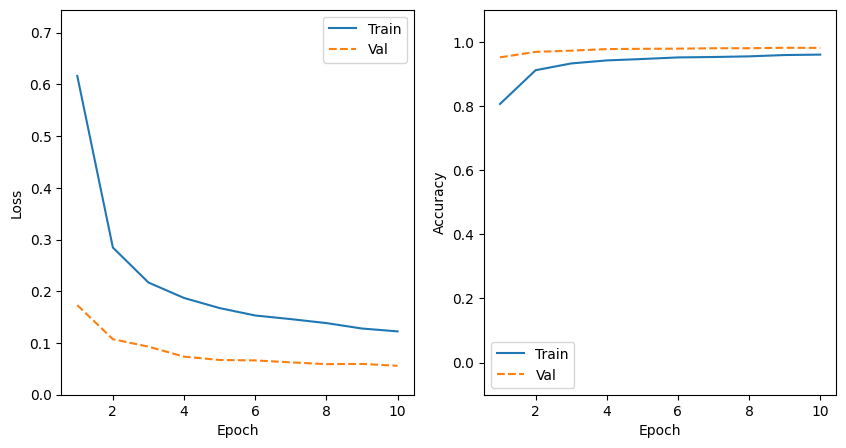

In [56]:
plot_metrics(smaller_dense_history)

In [57]:
smaller_dense_loss, smaller_dense_acc = evaluate(
    smaller_dense_model,
    test_loader,
    nn.CrossEntropyLoss()
)

print("Smaller dense CNN accuracy: %.3f" % smaller_dense_acc)
print("Smaller dense CNN loss: %.3f" % smaller_dense_loss)
print("Smaller dense CNN parameters:", count_parameters(smaller_dense_model))

Smaller dense CNN accuracy: 0.981
Smaller dense CNN loss: 0.060
Smaller dense CNN parameters: 173738


In [58]:
model4_loss, model4_acc = evaluate(
    model4,
    test_loader,
    nn.CrossEntropyLoss()
)

print("Model 4 accuracy: %.3f" % model4_acc)
print("Model 4 loss: %.3f" % model4_loss)
print("Model 4 parameters:", count_parameters(model4))

Model 4 accuracy: 0.985
Model 4 loss: 0.046
Model 4 parameters: 542230


The smaller dense CNN reached 0.981 accuracy with 173,738 parameters.

Compared with Model 4, this reduced the parameter count substantially while keeping almost the same accuracy. This is a better accuracy-complexity trade-off than the larger dense model.

In [59]:
results = [
    {
        "Model": "Baseline",
        "Accuracy": baseline_acc,
        "Parameters": count_parameters(baseline)
    },
    {
        "Model": "Model 1: 1x1 conv + pooling",
        "Accuracy": model1_acc,
        "Parameters": count_parameters(model1)
    },
    {
        "Model": "Model 2: 3x3 conv + pooling",
        "Accuracy": model2_acc,
        "Parameters": count_parameters(model2)
    },
    {
        "Model": "Model 3: 32 filters",
        "Accuracy": model3_acc,
        "Parameters": count_parameters(model3)
    },
    {
        "Model": "Model 4: 32 filters + dense",
        "Accuracy": model4_acc,
        "Parameters": count_parameters(model4)
    },
    {
        "Model": "Compact CNN",
        "Accuracy": compact_acc,
        "Parameters": count_parameters(compact_model)
    },
    {
        "Model": "Compact CNN + augmentation",
        "Accuracy": compact_augmented_acc,
        "Parameters": count_parameters(compact_augmented_model)
    },
    {
        "Model": "Smaller dense CNN",
        "Accuracy": smaller_dense_acc,
        "Parameters": count_parameters(smaller_dense_model)
    }
]

for result in results:
    print(
        f"{result['Model']:<35} "
        f"Accuracy: {result['Accuracy']:.3f} | "
        f"Parameters: {result['Parameters']}"
    )

Baseline                            Accuracy: 0.923 | Parameters: 7852
Model 1: 1x1 conv + pooling         Accuracy: 0.114 | Parameters: 1972
Model 2: 3x3 conv + pooling         Accuracy: 0.923 | Parameters: 1710
Model 3: 32 filters                 Accuracy: 0.982 | Parameters: 54410
Model 4: 32 filters + dense         Accuracy: 0.985 | Parameters: 542230
Compact CNN                         Accuracy: 0.885 | Parameters: 5130
Compact CNN + augmentation          Accuracy: 0.888 | Parameters: 5130
Smaller dense CNN                   Accuracy: 0.981 | Parameters: 173738


## Final discussion

The experiments show a clear trade-off between accuracy and model complexity.

The baseline reached 0.923 accuracy with 7,852 parameters. Model 2 achieved the same accuracy with only 1,710 parameters, making it the strongest parameter-reduction result.

Model 3 improved accuracy to 0.982 by increasing the number of convolutional filters to 32. This shows that more filters help the CNN learn a richer set of digit features.

Model 4 achieved the highest accuracy, 0.985, but required 542,230 parameters. The improvement over Model 3 was small compared with the increase in parameter count.

The compact CNN had only 5,130 parameters, but its accuracy was lower at 0.885. Mild augmentation improved it only slightly to 0.888.

The smaller dense CNN reached 0.981 accuracy with 173,738 parameters. This kept almost the same accuracy as Model 4 while using far fewer parameters.

## Conclusion

The best accuracy was achieved by Model 4, with 0.985 accuracy, but it was also the largest model.

The best parameter-efficiency result was Model 2, which matched the baseline accuracy while reducing the number of parameters from 7,852 to 1,710.

The best practical trade-off was Model 3 or the smaller dense CNN. Model 3 achieved 0.982 accuracy with 54,410 parameters, while the smaller dense CNN achieved 0.981 accuracy with 173,738 parameters.

Overall, adding useful convolutional filters improved accuracy more efficiently than adding a large dense layer.